In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
# ====== CONFIGURATION ======
ZIP_PATH = "DATASET FINAL.zip"  # Path to ZIP file
EXTRACT_PATH = "DATASET FINAL/DATASET FINAL/DATASET FINAL"  # Extraction folder
IMAGE_SIZE = (128, 128)  # Image dimensions
EPOCHS = 10
BATCH_SIZE = 8
MODEL_PATH = "currency_classifier.h5"  # Model save path


In [3]:
# ====== UNZIP THE DATASET ======
if not os.path.exists(EXTRACT_PATH):  # Check if already extracted
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f"✅ Extracted dataset to {EXTRACT_PATH}")
else:
    print(f"⚡ Dataset already extracted at {EXTRACT_PATH}")


⚡ Dataset already extracted at DATASET FINAL/DATASET FINAL/DATASET FINAL


In [4]:
# ====== FUNCTION TO LOAD IMAGES ======
def load_images_from_folder(folder, label):
    images, labels = [], []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)  # Load & resize image
            img_array = img_to_array(img) / 255.0  # Normalize
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"❌ Error loading image {filename}: {e}")
    return np.array(images), np.array(labels)

# ====== LOAD DATASET ======
all_images, all_labels = [], []
denominations = ["100 Rupees", "10_rupees", "20 Rupees", "200_rupees", "50 Rupees", "500 Rupees"]  # Currency types

for denomination in denominations:
    real_folder = os.path.join(EXTRACT_PATH, denomination, "Real")
    fake_folder = os.path.join(EXTRACT_PATH, denomination, "Fake")
    
    if os.path.exists(real_folder):
        real_images, real_labels = load_images_from_folder(real_folder, label=1)
        all_images.append(real_images)
        all_labels.append(real_labels)
    
    if os.path.exists(fake_folder):
        fake_images, fake_labels = load_images_from_folder(fake_folder, label=0)
        all_images.append(fake_images)
        all_labels.append(fake_labels)

# Combine all images and labels
X = np.concatenate(all_images)
y = np.concatenate(all_labels)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Dataset Loaded! Total Images: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)}")



❌ Error loading image 9.avif: cannot identify image file <_io.BytesIO object at 0x0000017C66718720>
❌ Error loading image 8.avif: cannot identify image file <_io.BytesIO object at 0x0000017C66718720>
✅ Dataset Loaded! Total Images: 225 | Train: 180 | Test: 45


In [5]:
# ====== BUILD CNN MODEL ======
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(*IMAGE_SIZE, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # Binary classification (Real = 1, Fake = 0)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

# ====== TRAIN MODEL ======
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=EPOCHS, batch_size=BATCH_SIZE)

# Save the trained model
model.save(MODEL_PATH)
print(f"✅ Model saved at {MODEL_PATH}")

Epoch 1/10
23/23 [==============================] - 6s 184ms/step - loss: 1.0985 - accuracy: 0.5611 - val_loss: 0.8586 - val_accuracy: 0.5333
Epoch 2/10
23/23 [==============================] - 3s 147ms/step - loss: 0.5720 - accuracy: 0.7333 - val_loss: 0.5849 - val_accuracy: 0.7111
Epoch 3/10
23/23 [==============================] - 4s 159ms/step - loss: 0.4604 - accuracy: 0.7778 - val_loss: 0.5328 - val_accuracy: 0.6444
Epoch 4/10
23/23 [==============================] - 3s 145ms/step - loss: 0.3458 - accuracy: 0.8444 - val_loss: 0.8807 - val_accuracy: 0.6667
Epoch 5/10
23/23 [==============================] - 3s 135ms/step - loss: 0.3220 - accuracy: 0.8944 - val_loss: 0.5560 - val_accuracy: 0.8000
Epoch 6/10
23/23 [==============================] - 3s 144ms/step - loss: 0.2805 - accuracy: 0.8833 - val_loss: 0.4693 - val_accuracy: 0.8444
Epoch 7/10
23/23 [==============================] - 3s 151ms/step - loss: 0.1999 - accuracy: 0.9000 - val_loss: 0.5059 - val_accuracy: 0.8444
Epoch 

In [6]:

import os
MODEL_PATH = os.path.abspath("currency_model.h5")
print(f"Model path: {MODEL_PATH}")



Model path: C:\Users\Shafni\Documents\Shafni-PG-PROJECT\FakeCurrencyDetection\currency_model.h5


In [7]:
# ====== PRINT FINAL EPOCH ACCURACY ======
final_epoch = EPOCHS - 1
print(f"Final Epoch ({EPOCHS}): ✅ Training Accuracy: {history.history['accuracy'][final_epoch] * 100:.2f}%, Validation Accuracy: {history.history['val_accuracy'][final_epoch] * 100:.2f}%")

# ====== EVALUATE MODEL ======
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")

Final Epoch (10): ✅ Training Accuracy: 95.00%, Validation Accuracy: 80.00%
2/2 [==============================] - 0s 64ms/step - loss: 0.8185 - accuracy: 0.8000
✅ Test Accuracy: 80.00%


2/2 [==============================] - 0s 55ms/step
Confusion Matrix:
[[15  6]
 [ 3 21]]


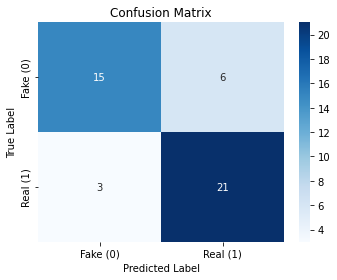


True Negatives (Fake correctly classified): 15
False Positives (Fake predicted as Real): 6
False Negatives (Real predicted as Fake): 3
True Positives (Real correctly classified): 21


In [8]:
# ====== CONFUSION MATRIX ======
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities
y_prob = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_prob > 0.5).astype(int)

# Flatten arrays to avoid shape issues
y_pred = y_pred.reshape(-1)
y_true = y_test.reshape(-1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# Print detailed counts
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Fake correctly classified): {tn}")
print(f"False Positives (Fake predicted as Real): {fp}")
print(f"False Negatives (Real predicted as Fake): {fn}")
print(f"True Positives (Real correctly classified): {tp}")

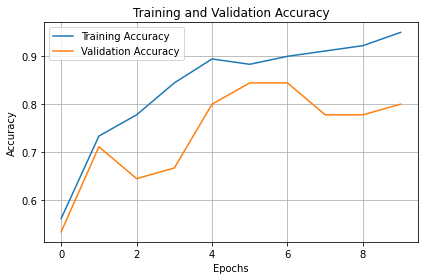

In [9]:
# ====== TRAINING vs VALIDATION ACCURACY GRAPH ======
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_validation_accuracy.png", dpi=300)
plt.show()

2/2 [==============================] - 0s 40ms/step


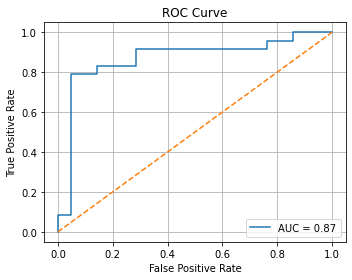

AUC Score: 0.8690


In [10]:
# ====== ROC CURVE ======
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities
y_prob = model.predict(X_test).reshape(-1)
y_true = y_test.reshape(-1)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [11]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

2/2 [==============================] - 0s 43ms/step - loss: 0.8185 - accuracy: 0.8000
Test Accuracy: 80.00%
